In [3]:
from __future__ import annotations

from pathlib import Path
from typing import Any
import json

import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

import yaml

from pydantic import BaseModel
from typing import Literal
from openai import OpenAI

def load_events(results_file: str | Path) -> pd.DataFrame:
    """Load events.jsonl file into a single DataFrame."""
    path = Path(results_file)
    frames = []
    rows = [json.loads(line) for line in path.read_text(encoding="utf-8").splitlines() if line]
    if rows:
        frames.append(pd.DataFrame(rows))
    if not frames:
        return pd.DataFrame()
    df = pd.concat(frames, ignore_index=True)
    return df

def load_all_events(results_files: list) -> pd.DataFrame:
    all_dfs = []
    for rf in results_files:
        temp_df = load_events(rf)
        all_dfs.append(temp_df)
    return pd.concat(all_dfs, ignore_index=True)


def _load_analysis_config(config: dict[str, Any] | str | Path | None) -> dict[str, Any] | None:
    if config is None or isinstance(config, dict):
        return config
    path = Path(config)
    text = path.read_text(encoding="utf-8")
    if path.suffix.lower() == ".json":
        return json.loads(text)
    return yaml.safe_load(text)


exp_name = 'left-digit'

results_dir = Path('/home/dw/github/toollab/results/')/exp_name

def get_data(exp_name):
    results_files = list(results_dir.glob('*-events.jsonl'))
    config_files = list(results_dir.glob('*-config.json'))
    config_file = config_files[0] if config_files else None
    config = _load_analysis_config(config_file)
    metadata_columns = list(config['metadata'].keys())
    # print('metadata_columns', metadata_columns)

    df_raw = load_all_events(results_files)
    df = df_raw.copy().sort_values(['session_name', 'step_index'])
    meta_df = df['meta'].dropna().apply(pd.Series)
    meta_df = meta_df.add_prefix('meta_')
    if not meta_df.empty:
        df = df.join(meta_df)

    meta_cols = df.filter(like='meta_').columns
    df[meta_cols] = df.groupby('session_name')[meta_cols].ffill()
    return df, config

df, config = get_data(exp_name)
# print(f"{len(df)} events across {df['session_name'].nunique()} sessions")
# print(df[['option_count', 'design']])
print(df.columns)
print(df.shape)

print("\nNumber of sessions per condition:")

# df.groupby(['model_name', *metadata_columns])['session_name'].nunique().reset_index()

gemini_flash_lite = df[(df['model_name']=='gemini-3.1-flash-lite-preview')&(df['kind']=='tool')]
# gemini_flash_lite[['budget_type', 'budget_max','choice','step_index','option_id', 'attribute_id', 'value', 'transition']]
df

TypeError: 'NoneType' object is not subscriptable

### Transitions

In [21]:
gemini_flash = df[(df['model_name']=='gemini-3-flash-preview')&(df['kind']=='tool')]
# gemini_lite.columns
gemini_flash[['budget_type', 'budget_max','choice','step_index','option_id', 'attribute_id', 'value', 'transition']]


,budget_type,budget_max,choice,step_index,option_id,attribute_id,value,transition
1,NaN,NaN,coffee_a,2,coffee_a,price_dollars,$12,first
3,NaN,NaN,coffee_a,4,coffee_b,price_dollars,$13,attribute
5,NaN,NaN,coffee_a,6,coffee_a,weight_oz,13.0 oz,diagonal
7,NaN,NaN,coffee_a,8,coffee_b,weight_oz,13.9 oz,attribute
9,NaN,NaN,coffee_a,10,coffee_a,price_cents,.99,diagonal
11,NaN,NaN,coffee_a,12,coffee_a,NaN,NaN,NaN
13,NaN,NaN,coffee_b,2,coffee_a,price_dollars,$12,first
15,NaN,NaN,coffee_b,4,coffee_a,price_cents,.99,alternative
17,NaN,NaN,coffee_b,6,coffee_a,weight_oz,13.0 oz,alternative
19,NaN,NaN,coffee_b,8,coffee_b,price_dollars,$13,diagonal


In [22]:
gpt = df[(df['model_name'].str.contains('gpt'))&(df['kind']=='tool')]
# gemini_lite.columns
gpt[['model_name', 'budget_max','choice','step_index','option_id', 'attribute_id', 'value', 'transition']]


,model_name,budget_max,choice,step_index,option_id,attribute_id,value,transition
115,gpt-5.4-mini,5.0,coffee_b,2,coffee_a,price_dollars,$12,first
117,gpt-5.4-mini,5.0,coffee_b,4,coffee_a,price_cents,.99,alternative
119,gpt-5.4-mini,5.0,coffee_b,6,coffee_a,weight_oz,13.0 oz,alternative
121,gpt-5.4-mini,5.0,coffee_b,8,coffee_b,price_dollars,$13,diagonal
123,gpt-5.4-mini,5.0,coffee_b,10,coffee_b,weight_oz,13.9 oz,alternative
125,gpt-5.4-mini,5.0,coffee_b,12,coffee_b,NaN,NaN,NaN
127,gpt-5.4,5.0,coffee_b,2,coffee_a,price_dollars,$12,first
129,gpt-5.4,5.0,coffee_b,4,coffee_a,price_cents,.99,alternative
131,gpt-5.4,5.0,coffee_b,6,coffee_a,weight_oz,13.0 oz,alternative
133,gpt-5.4,5.0,coffee_b,8,coffee_b,price_dollars,$13,diagonal


In [34]:
df.columns

Index(['session_name', 'experiment_name', 'provider', 'model_name',
       'forced_choice', 'choice', 'cumulative_cost_usd',
       'budget_remaining_usd', 'cumulative_cost_tools',
       'budget_remaining_tools', 'option_count', 'seed', 'started_at',
       'finished_at', 'step_index', 'kind', 'content', 'reasoning',
       'input_tokens', 'output_tokens', 'input_cost', 'output_cost',
       'tool_cost', 'tool_calls', 'finish_reason', 'tool_name', 'tool_call_id',
       'option_id', 'attribute_id', 'value', 'turn_cost_tools', 'is_revisit',
       'transition', 'option_label', 'budget_type', 'budget_max',
       'budget_remaining_tokens', 'cumulative_cost_tokens', 'turn_cost_tokens',
       'meta', 'meta_gpt-5.4-mini-2026-03-17', 'meta_none',
       'meta_gpt-5.4-2026-03-05', 'meta_gpt-5.4-nano-2026-03-17',
       'meta_claude-sonnet-4-6', 'meta_thinking', 'meta_effort',
       'meta_model_version'],
      dtype='str')

In [35]:
df

,session_name,experiment_name,provider,model_name,forced_choice,choice,cumulative_cost_usd,budget_remaining_usd,cumulative_cost_tools,budget_remaining_tools,...,turn_cost_tokens,meta,meta_gpt-5.4-mini-2026-03-17,meta_none,meta_gpt-5.4-2026-03-05,meta_gpt-5.4-nano-2026-03-17,meta_claude-sonnet-4-6,meta_thinking,meta_effort,meta_model_version
0,20260409T201335248464Z,left-digit,google,gemini-3-flash-preview,False,coffee_a,0.000309,-0.000309,1,4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,20260409T201335248464Z,left-digit,google,gemini-3-flash-preview,False,coffee_a,0.000309,-0.000309,1,4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,20260409T201335248464Z,left-digit,google,gemini-3-flash-preview,False,coffee_a,0.001107,-0.001107,2,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,20260409T201335248464Z,left-digit,google,gemini-3-flash-preview,False,coffee_a,0.001107,-0.001107,2,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,20260409T201335248464Z,left-digit,google,gemini-3-flash-preview,False,coffee_a,0.002083,-0.002083,3,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
225,20260410T163414801115Z,left-digit,llamacpp,gemma-4-26B-A4B-it-UD-Q4_K_XL.gguf,False,coffee_b,0.000000,0.000000,4,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,gemma-4-26B-A4B-it-UD-Q4_K_XL.gguf
226,20260410T163414801115Z,left-digit,llamacpp,gemma-4-26B-A4B-it-UD-Q4_K_XL.gguf,False,coffee_b,0.000000,0.000000,5,0,...,NaN,{'model_version': 'gemma-4-26B-A4B-it-UD-Q4_K_...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,gemma-4-26B-A4B-it-UD-Q4_K_XL.gguf
227,20260410T163414801115Z,left-digit,llamacpp,gemma-4-26B-A4B-it-UD-Q4_K_XL.gguf,False,coffee_b,0.000000,0.000000,5,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,gemma-4-26B-A4B-it-UD-Q4_K_XL.gguf
228,20260410T163414801115Z,left-digit,llamacpp,gemma-4-26B-A4B-it-UD-Q4_K_XL.gguf,False,coffee_b,0.000000,0.000000,5,0,...,NaN,{'model_version': 'gemma-4-26B-A4B-it-UD-Q4_K_...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,gemma-4-26B-A4B-it-UD-Q4_K_XL.gguf


In [32]:
anthropic = df[(df['provider'].str.contains('anthropic'))&(df['kind']=='tool')]
# gemini_lite.columns
anthropic[['model_name', 'meta_thinking', 'meta_effort', 'budget_max','choice','step_index','option_id', 'attribute_id', 'value', 'transition']]


,model_name,meta_thinking,meta_effort,budget_max,choice,step_index,option_id,attribute_id,value,transition
175,claude-sonnet-4-6,NaN,NaN,5.0,coffee_b,2,coffee_a,price_dollars,$12,first
177,claude-sonnet-4-6,NaN,NaN,5.0,coffee_b,4,coffee_a,price_cents,.99,alternative
179,claude-sonnet-4-6,NaN,NaN,5.0,coffee_b,6,coffee_a,weight_oz,13.0 oz,alternative
181,claude-sonnet-4-6,NaN,NaN,5.0,coffee_b,8,coffee_b,price_dollars,$13,diagonal
183,claude-sonnet-4-6,NaN,NaN,5.0,coffee_b,10,coffee_b,weight_oz,13.9 oz,alternative
185,claude-sonnet-4-6,NaN,NaN,5.0,coffee_b,12,coffee_b,NaN,NaN,NaN
187,claude-sonnet-4-6,NaN,NaN,5.0,coffee_a,2,coffee_a,price_dollars,$12,first
189,claude-sonnet-4-6,NaN,NaN,5.0,coffee_a,4,coffee_b,price_dollars,$13,attribute
191,claude-sonnet-4-6,NaN,NaN,5.0,coffee_a,6,coffee_a,weight_oz,13.0 oz,diagonal
193,claude-sonnet-4-6,NaN,NaN,5.0,coffee_a,8,coffee_b,weight_oz,13.9 oz,attribute


In [3]:
scores = {opt['id']:opt['base_score'] for opt in config['options']}
scores

{'coffee_a': 1.00077, 'coffee_b': 1.06923}

In [4]:
# df['budget_type']

In [5]:
session_choices = df.groupby(['model_name','session_name'])['choice'].last().reset_index()
session_choices['score'] = session_choices['choice'].map(scores)
session_choices

,model_name,session_name,choice,score
0,gemini-3-flash-preview,20260409T201335248464Z,coffee_a,1.00077
1,gemini-3-flash-preview,20260409T202110975586Z,coffee_b,1.06923
2,gemini-3-flash-preview,20260409T213551363719Z,coffee_a,1.00077
3,gemini-3-flash-preview,20260409T224320378210Z,coffee_a,1.00077
4,gemini-3.1-flash-lite-preview,20260409T205849239956Z,coffee_a,1.00077
5,gemini-3.1-flash-lite-preview,20260409T205948438333Z,coffee_a,1.00077
6,gemini-3.1-flash-lite-preview,20260409T212306149951Z,coffee_a,1.00077
7,gemini-3.1-flash-lite-preview,20260409T212652870379Z,coffee_a,1.00077
8,gemini-3.1-flash-lite-preview,20260409T213049600406Z,coffee_b,1.06923
9,gemini-3.1-flash-lite-preview,20260409T213418124240Z,coffee_a,1.00077


In [6]:
(df[(df['choice']=='coffee_b')&(df['tool_name']=='inspect_cell')])[['step_index','option_id', 'attribute_id', 'value']]

,step_index,option_id,attribute_id,value
13,2,coffee_a,price_dollars,$12
15,4,coffee_a,price_cents,.99
17,6,coffee_a,weight_oz,13.0 oz
19,8,coffee_b,price_dollars,$13
21,10,coffee_b,weight_oz,13.9 oz
76,2,coffee_a,price_dollars,$12
78,4,coffee_a,price_cents,.99
80,6,coffee_a,weight_oz,13.0 oz
82,8,coffee_b,price_dollars,$13
84,10,coffee_b,price_cents,.00


In [84]:
13/12.99 # value

1.0007698229407236

In [85]:
print('worst case',13.99/13.99) # worst case
print('best case', 13.99/13.00) # best case

worst case 1.0
best case 1.0761538461538462


### Verbal protocol analysis

In [4]:
df['provider'].value_counts()

provider
google       472
llamacpp     346
mock         134
anthropic     20
Name: count, dtype: int64

In [13]:
has_reasoning  = df[(~df['reasoning'].isna()) & (df['reasoning']!='') & (df['provider']!='mock')]

has_reasoning['tc'] = has_reasoning['tool_calls'].apply(lambda l: l[0])
has_reasoning['t_name'] = has_reasoning['tc'].apply(lambda x: x.get('name'))
has_reasoning['t_option'] = has_reasoning['tc'].apply(lambda x: x.get('arguments').get('option_id'))
has_reasoning['t_attribute'] = has_reasoning['tc'].apply(lambda x: x.get('arguments').get('attribute_id'))

cue_lookup = {(c['option_id'], c['attribute_id']): c['value'] for c in config.get('cues', [])}
# Create the new value column by mapping over each row
has_reasoning['t_value'] = has_reasoning.apply(lambda row: cue_lookup.get((row['t_option'], row['t_attribute'])), axis=1)

has_reasoning[['t_name', 't_option', 't_attribute']].head()

has_reasoning[['reasoning', 'model_name']]['model_name'].value_counts()
# has_reasoning['reasoning']

model_name
gemini-3.1-pro-preview                131
gemini-3-flash-preview                105
Qwen3.5-27B-UD-Q4_K_XL.gguf            86
gemma-4-31B-it-UD-Q4_K_XL.gguf         52
gemma-4-26B-A4B-it-UD-Q4_K_XL.gguf     22
Name: count, dtype: int64

In [15]:
has_reasoning[['t_name', 't_option', 't_attribute']]


,t_name,t_option,t_attribute
0,inspect_cell,coffee_a,price
2,inspect_cell,coffee_a,weight_oz
4,inspect_cell,coffee_b,price
6,inspect_cell,coffee_b,weight_oz
8,inspect_cell,coffee_a,list_price
...,...,...,...
942,inspect_cell,coffee_a,weight_oz
944,inspect_cell,coffee_b,weight_oz
946,inspect_cell,coffee_c,weight_oz
948,inspect_cell,coffee_a,discount_percentage


In [11]:
# has_reasoning[['step_index', 't_name', 't_option', 't_attribute', 't_value']].tail(10)

In [10]:
has_reasoning_geminipro = has_reasoning[(has_reasoning['model_name']=='gemini-3.1-pro-preview')&(has_reasoning['budget_type']=='points')]
# has_reasoning_geminipro
# for i, row in (has_reasoning_geminipro[['step_index', 'model_name','budget_type', 'budget_max', 'reasoning', 't_name', 't_option', 't_attribute', 't_value']]).iterrows():
#     print(row.to_csv())
#     print('+'*50)

### classify final reasoning

In [ ]:
client = OpenAI(
    base_url='http://localhost:8080/v1',
    api_key="sk-no-key-required"
)
class ChoiceClassification(BaseModel):
    label: Literal["price per weight value", "discount"]

def classify_reasoning(reasoning_text: str) -> str:
    # Initialize the OpenAI client pointing to the local Llama Cpp server
    system_prompt = (
        "You are a highly precise data annotator analyzing the decision-making process of AI models. "
        "You will be provided with the reasoning an AI model gave for choosing a specific product. "
        "Your task is to identify the primary factor or attribute that drove the model's choice.\n\n"
        "Classify the reasoning into exactly one of two categories:\n"
        "1. 'price per weight value' (if the choice is based on unit price, weight-to-price ratio, or getting more product for the money)\n"
        "2. 'discount' (if the choice is based on a price reduction, sale, or percentage off the original retail price)\n\n"
        # "You must output only the exact category name and nothing else. Do not include any explanations or punctuation."
    )
    
    user_prompt = reasoning_text


    try:
        response = client.chat.completions.parse(
            model="gemma-4-31B-it-UD-Q4_K_XL.gguf", # The model name doesn't matter for the local llama.cpp server
            messages=[
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": user_prompt}
            ],
            response_format=ChoiceClassification,
        )
        
        # Extract and clean up the classification result
        # print(response.choices[0])
        category = response.choices[0].message.parsed
        return category.label
        
    except Exception as e:
        print(f"An error occurred: {e}")
        return "Error"



In [71]:
# sample = has_reasoning_submit_choice.iloc[0]['reasoning']
# print(sample)
# classification = classify_reasoning(sample)
# print(classification)

In [68]:
has_reasoning_submit_choice = has_reasoning[has_reasoning['t_name']=='submit_choice']
has_reasoning_submit_choice['class_choice'] = has_reasoning_submit_choice['reasoning'].apply(classify_reasoning)

In [70]:
has_reasoning_submit_choice.groupby('model_name')['class_choice'].value_counts()

model_name                          class_choice          
Qwen3.5-27B-UD-Q4_K_XL.gguf         discount                   5
                                    price per weight value     4
gemini-3-flash-preview              price per weight value     8
                                    discount                   3
gemini-3.1-pro-preview              price per weight value    15
                                    discount                   7
gemma-4-26B-A4B-it-UD-Q4_K_XL.gguf  price per weight value     5
gemma-4-31B-it-UD-Q4_K_XL.gguf      price per weight value     6
                                    discount                   2
Name: count, dtype: int64

In [17]:
has_reasoning[['step_index','reasoning', 't_name']]

,step_index,reasoning,t_name
0,1,"**My Strategy for Coffee Selection**\n\nOkay, ...",inspect_cell
2,3,"Okay, here's my thought process on this:\n\n**...",inspect_cell
4,5,"Okay, here's my take on those thoughts, framed...",inspect_cell
6,7,"Okay, here's my take on those thoughts, framed...",inspect_cell
8,9,"Okay, here's my breakdown of this quick coffee...",inspect_cell
...,...,...,...
942,11,**Analyzing the Sale Price Discrepancy**\n\nOk...,inspect_cell
944,13,"Okay, here's my interpretation of that thought...",inspect_cell
946,15,"Okay, here's my interpretation of that thought...",inspect_cell
948,17,"Okay, here's my take on those thoughts, framed...",inspect_cell


# the effect of constraint on choice

### max steps taken

<Axes: xlabel='budget_max', ylabel='is_inspect'>

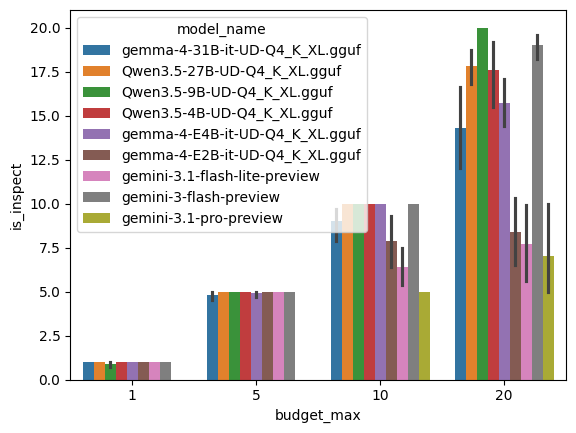

In [171]:
df, config = get_data(exp_name)

df_copy = df.copy()
df_copy['is_inspect'] = df_copy['tool_name'] == 'inspect_cell'

num_inspect = df_copy.groupby('session_name').agg({
    'model_name':'first',
    'budget_max':'first',
    'is_inspect': 'sum',
})
# num_inspect.plot(kind='bar', x = 'budget_max', y='is_inspect')
sns.barplot(data=num_inspect, x = 'budget_max', y = 'is_inspect', hue='model_name')

### gemini

In [177]:
df, config = get_data(exp_name)
df_gemini = df[df['model_name'].str.contains('gemini')]

reasoning_df = df_gemini[df_gemini['tool_calls'].str[0].str.get('name') == 'submit_choice'] \
                .groupby('session_name')['reasoning'].first()

# 2. Your existing aggregation
most_important_attribute = (df_gemini[df_gemini['tool_name']=='submit_choice']).groupby(['session_name']).agg({
    'model_name': 'first',
    'budget_max': 'first',
    'most_important_attribute':'first',
})

# 3. Combine them using a join
submit_choice_reasoning = most_important_attribute.join(reasoning_df)
sample = submit_choice_reasoning.iloc[0]
submit_choice_reasoning.groupby(['model_name','budget_max']).count()

most_important_attribute  reasoning
model_name                    budget_max                                     
gemini-3-flash-preview        1                                 10         10
                              5                                 10         10
                              10                                10         10
                              20                                10         10
gemini-3.1-flash-lite-preview 1                                 10         10
                              5                                 10         10
                              10                                10         10
                              20                                10         10
gemini-3.1-pro-preview        1                                 10         10
                              5                                 10         10
                              10                                10         10
                              20                                10         10

In [181]:
import statsmodels.formula.api as smf

model_name_to_size_dict = {
    'gemini-3.1-flash-lite-preview':'small',        
    'gemini-3-flash-preview':'medium',
    'gemini-3.1-pro-preview':'large',
}

# Convert the boolean column to integer (0 or 1) for the model
submit_choice_reasoning['discount_target'] = (submit_choice_reasoning['most_important_attribute']=='discount_percentage').astype(int)
submit_choice_reasoning['model_size'] = submit_choice_reasoning['model_name'].map(model_name_to_size_dict)

# Fit the logistic regression model
# This tests if continuous 'budget_max' predicts the binary 'discount_target'
logit_model = smf.logit('discount_target ~ budget_max + model_size ', data=submit_choice_reasoning).fit()

# Display the statistical summary
print(logit_model.summary())

Optimization terminated successfully.
         Current function value: 0.304691
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:        discount_target   No. Observations:                  120
Model:                          Logit   Df Residuals:                      116
Method:                           MLE   Df Model:                            3
Date:                Wed, 15 Apr 2026   Pseudo R-squ.:                  0.1117
Time:                        19:06:58   Log-Likelihood:                -36.563
converged:                       True   LL-Null:                       -41.162
Covariance Type:            nonrobust   LLR p-value:                   0.02677
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                4.5022      1.150      3.915      0.000       2.248       6.756

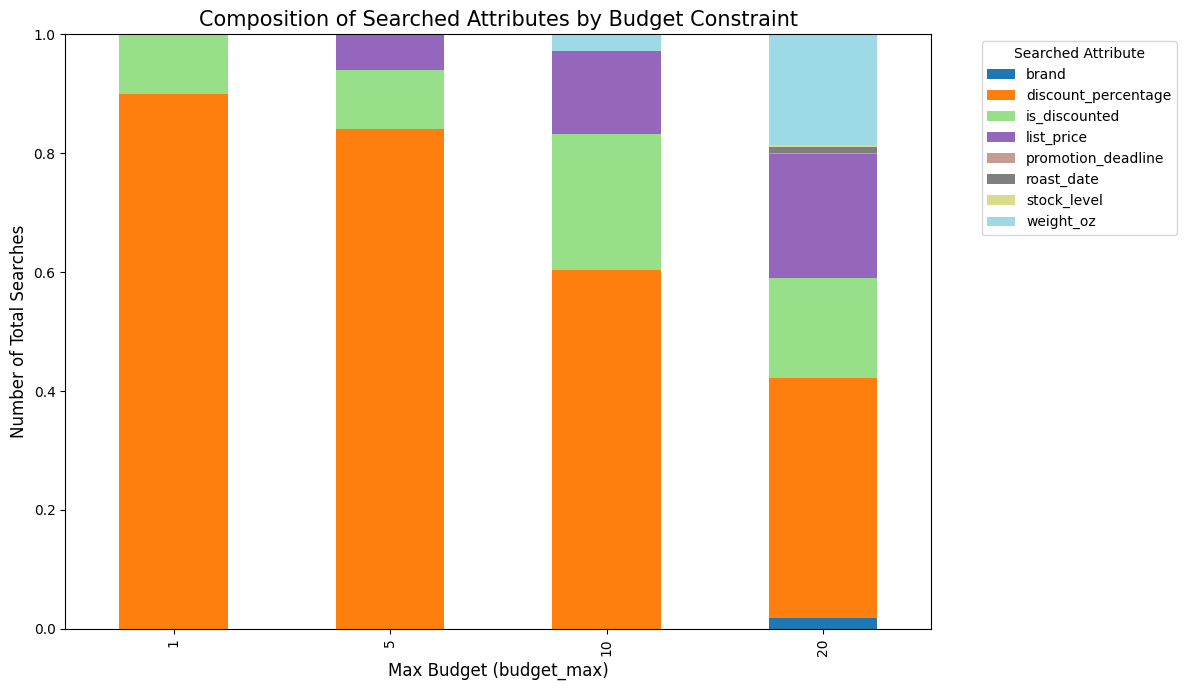

In [182]:
# 1. Create a crosstab directly from the raw df, normalizing by the row (budget)
search_proportions = pd.crosstab(
    df_gemini['budget_max'], 
    df_gemini['attribute_id'], 
    normalize='index' # Converts counts to percentages (0.0 to 1.0)
)

# 2. Plot as a Stacked Bar Chart
search_proportions.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='tab20')

plt.title('Composition of Searched Attributes by Budget Constraint', fontsize=15)
plt.xlabel('Max Budget (budget_max)', fontsize=12)
plt.ylabel('Number of Total Searches', fontsize=12)
plt.legend(title='Searched Attribute', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [186]:
submit_choice_reasoning['most_important_attribute'].value_counts()

most_important_attribute
discount_percentage        107
weight_oz                    4
is_discounted                3
list_price                   2
discounted_price_per_oz      1
list_price_per_oz            1
list_price and discount      1
list_price/discount          1
Name: count, dtype: int64

### Classify choice reasoning on attribute

In [95]:
from tool_lab.models.llamacpp_adapter import LlamaCppClient
class Config:
    model_name = 'gemma-4-31B-it-UD-Q4_K_XL.gguf'

LlamaCppClient(Config())

client = OpenAI(
    base_url='http://localhost:8080/v1',
    api_key="sk-no-key-required"
)
attribute_list = [att['id'] for att in config['attributes']]

class AttributeClassification(BaseModel):
    label: Literal[*attribute_list]

def classify_choice_attribute(reasoning_text: str) -> str:
    if not reasoning_text: return 'No_Reasoning'
    # Initialize the OpenAI client pointing to the local Llama Cpp server
    attribute_string = ''
    for att in attribute_list:
        attribute_string+=f'- "{att}"\n'
    
    system_prompt = (
        "You are a highly precise data annotator analyzing the decision-making process of AI models. "
        "You will be provided with the reasoning an AI model gave for choosing a specific product. "
        "Your task is to identify the primary attribute that determined the model's final choice.\n\n"
        "Classify the reasoning into exactly one of these categories:\n"
        f'{attribute_string}'
    )
    
    user_prompt = reasoning_text

    try:
        response = client.chat.completions.parse(
            model="gemma-4-31B-it-UD-Q4_K_XL.gguf", # The model name doesn't matter for the local llama.cpp server
            messages=[
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": user_prompt}
            ],
            response_format=AttributeClassification,
        )
        
        # Extract and clean up the classification result
        # print(response.choices[0])
        category = response.choices[0].message.parsed
        return category.label
        
    except Exception as e:
        print(f"An error occurred: {e}")
        return "Error"
client.models.list()

Cache Dir: /home/dw/data/.lcpp_cache
_ensure_server running_model gemma-4-31B-it-UD-Q4_K_XL.gguf
_ensure_server self.config.model_name gemma-4-31B-it-UD-Q4_K_XL.gguf
[llama] Server already serving 'gemma-4-31B-it-UD-Q4_K_XL.gguf' – reusing.


SyncPage[Model](data=[Model(id='gemma-4-31B-it-UD-Q4_K_XL.gguf', created=1776292896, object='model', owned_by='llamacpp', aliases=[], tags=[], meta={'vocab_type': 2, 'n_vocab': 262144, 'n_ctx_train': 262144, 'n_embd': 5376, 'n_params': 30697345596, 'size': 18751396080})], object='list', models=[{'name': 'gemma-4-31B-it-UD-Q4_K_XL.gguf', 'model': 'gemma-4-31B-it-UD-Q4_K_XL.gguf', 'modified_at': '', 'size': '', 'digest': '', 'type': 'model', 'description': '', 'tags': [''], 'capabilities': ['completion'], 'parameters': '', 'details': {'parent_model': '', 'format': 'gguf', 'family': '', 'families': [''], 'parameter_size': '', 'quantization_level': ''}}])

In [ ]:
client.models.list()

In [157]:
most_important_attribute = (df[df['tool_name']=='submit_choice']).groupby(['session_name']).agg({
    'most_important_attribute':'first',
    'model_name': 'first'
})
most_important_attribute

,most_important_attribute,model_name
session_name,,
20260415T161414407849Z,discount_percentage,gemma-4-31B-it-UD-Q4_K_XL.gguf
20260415T161429371264Z,discount_percentage,gemma-4-31B-it-UD-Q4_K_XL.gguf
20260415T161443870482Z,discount_percentage,gemma-4-31B-it-UD-Q4_K_XL.gguf
20260415T161520966406Z,discount_percentage,gemma-4-31B-it-UD-Q4_K_XL.gguf
20260415T161604519148Z,discount_percentage,gemma-4-31B-it-UD-Q4_K_XL.gguf
...,...,...
20260415T232900107105Z,discount_percentage,gemini-3-flash-preview
20260415T232908851853Z,discount_percentage,gemini-3-flash-preview
20260416T011818303367Z,discount_percentage,gemini-3.1-pro-preview


In [158]:
reasoning_df = df[df['tool_calls'].str[0].str.get('name') == 'submit_choice'] \
                .groupby('session_name')['reasoning'].first()

# 2. Your existing aggregation
most_important_attribute = (df[df['tool_name']=='submit_choice']).groupby(['session_name']).agg({
    'model_name': 'first',
    'budget_max': 'first',
    'most_important_attribute':'first',
})

# 3. Combine them using a join
submit_choice_reasoning = most_important_attribute.join(reasoning_df)
sample = submit_choice_reasoning.iloc[0]
submit_choice_reasoning

,model_name,budget_max,most_important_attribute,reasoning
session_name,,,,
20260415T161414407849Z,gemma-4-31B-it-UD-Q4_K_XL.gguf,10,discount_percentage,\nThe goal is to find the best deal on coffee ...
20260415T161429371264Z,gemma-4-31B-it-UD-Q4_K_XL.gguf,5,discount_percentage,\nThe user wants me to find the best deal on c...
20260415T161443870482Z,gemma-4-31B-it-UD-Q4_K_XL.gguf,1,discount_percentage,\nThe user wants me to find the best coffee de...
20260415T161520966406Z,gemma-4-31B-it-UD-Q4_K_XL.gguf,1,discount_percentage,\nThe user wants me to find the best deal on c...
20260415T161604519148Z,gemma-4-31B-it-UD-Q4_K_XL.gguf,1,discount_percentage,\nThe user wants me to find the best deal on c...
...,...,...,...,...
20260415T232900107105Z,gemini-3-flash-preview,1,discount_percentage,**Decision Time: Limited Information and Budge...
20260415T232908851853Z,gemini-3-flash-preview,1,discount_percentage,"**My Decision: Option 1**\n\nOkay, here's the ..."
20260416T011818303367Z,gemini-3.1-pro-preview,20,discount_percentage,"**My Decision-Making Process**\n\nOkay, so I'm..."


In [159]:
submit_choice_reasoning.isna().sum()

model_name                  0
budget_max                  0
most_important_attribute    0
reasoning                   2
dtype: int64

In [ ]:
# submit_choice_reasoning['predicted_attribute'] = None
for i, row in submit_choice_reasoning.iterrows():
    predicted_attribute = classify_choice_attribute(row['reasoning'])
    submit_choice_reasoning.at[i, 'predicted_attribute'] = predicted_attribute
    print(row['model_name'], row['budget_max'], predicted_attribute, 'vs.', row['most_important_attribute'])

In [61]:
# submit_choice_reasoning.to_csv(results_dir/'predicted_attributes.csv')


In [93]:
submit_choice_reasoning = pd.read_csv(results_dir/'predicted_attributes.csv')
submit_choice_reasoning

,session_name,model_name,budget_max,most_important_attribute,reasoning,predicted_attribute
0,20260415T161414407849Z,gemma-4-31B-it-UD-Q4_K_XL.gguf,10,discount_percentage,\nThe goal is to find the best deal on coffee ...,weight_oz
1,20260415T161429371264Z,gemma-4-31B-it-UD-Q4_K_XL.gguf,5,discount_percentage,\nThe user wants me to find the best deal on c...,discount_percentage
2,20260415T161443870482Z,gemma-4-31B-it-UD-Q4_K_XL.gguf,1,discount_percentage,\nThe user wants me to find the best coffee de...,discount_percentage
3,20260415T161520966406Z,gemma-4-31B-it-UD-Q4_K_XL.gguf,1,discount_percentage,\nThe user wants me to find the best deal on c...,discount_percentage
4,20260415T161604519148Z,gemma-4-31B-it-UD-Q4_K_XL.gguf,1,discount_percentage,\nThe user wants me to find the best deal on c...,discount_percentage
...,...,...,...,...,...,...
235,20260415T211739771084Z,Qwen3.5-27B-UD-Q4_K_XL.gguf,20,discount_percentage,Option_3 is not discounted. So if we're lookin...,discount_percentage
236,20260415T211835575838Z,Qwen3.5-27B-UD-Q4_K_XL.gguf,20,weight_oz,Both option_1 and option_3 were roasted 2 week...,weight_oz
237,20260415T211933959232Z,Qwen3.5-27B-UD-Q4_K_XL.gguf,20,weight_oz,"Option_2 has only 3 left in stock, but it's st...",weight_oz
238,20260415T212023423393Z,Qwen3.5-27B-UD-Q4_K_XL.gguf,20,weight_oz,"Option 1: $12.60 (no discount), 11.5 oz\nPrice...",weight_oz


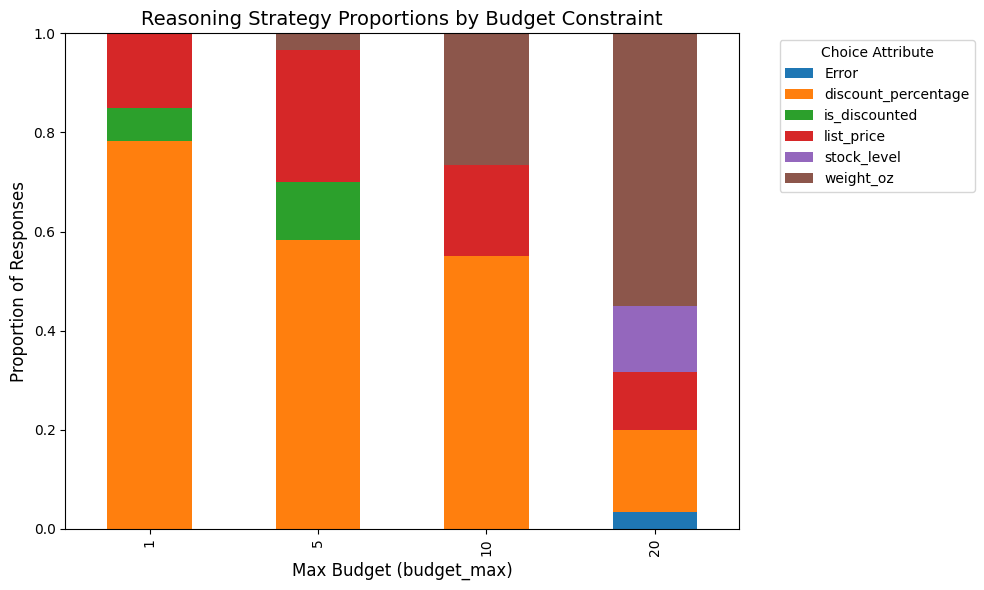

In [76]:
# 1. Create a cross-tabulation and normalize it so each row sums to 1.0 (100%)
crosstab_pred = pd.crosstab(
    submit_choice_reasoning['budget_max'], 
    submit_choice_reasoning['predicted_attribute'], 
    normalize='index' # This gives you percentages instead of raw counts
)

# 2. Plot as a stacked bar chart
ax = crosstab_pred.plot(kind='bar', stacked=True, figsize=(10, 6), )

plt.title('Reasoning Strategy Proportions by Budget Constraint', fontsize=14)
plt.xlabel('Max Budget (budget_max)', fontsize=12)
plt.ylabel('Proportion of Responses', fontsize=12)

# Move the legend outside the plot so it doesn't cover the bars
plt.legend(title='Choice Attribute', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

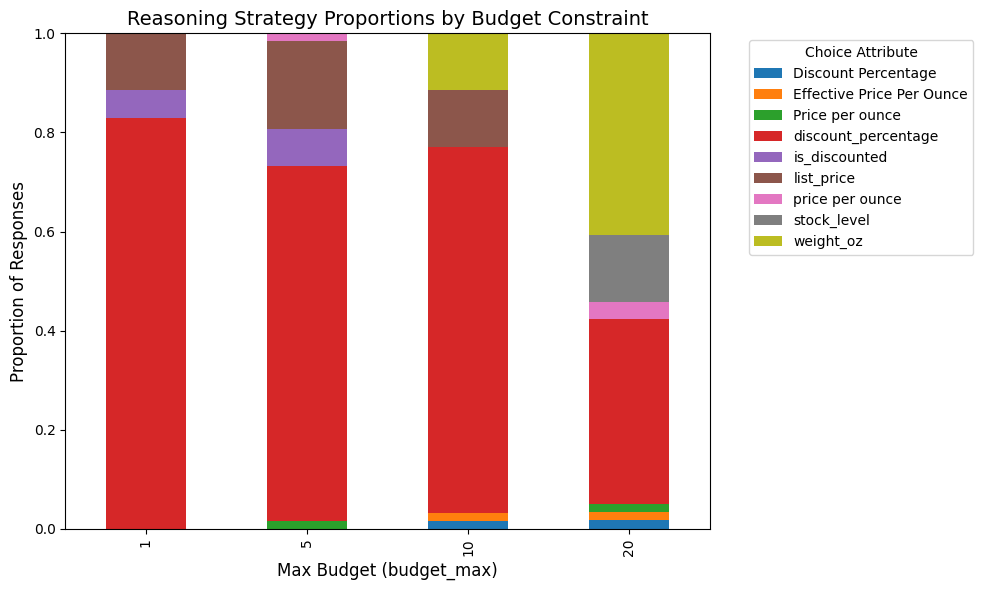

In [144]:
claimed_counts = submit_choice_reasoning['most_important_attribute'].value_counts()
top_claims = claimed_counts[claimed_counts>1].index
top_claims_df = submit_choice_reasoning[submit_choice_reasoning['most_important_attribute'].isin(top_claims)]
top_claims_df['most_important_attribute'].value_counts()

crosstab_claimed = pd.crosstab(
    top_claims_df['budget_max'], 
    top_claims_df['most_important_attribute'], 
    normalize='index' # This gives you percentages instead of raw counts
)

# 2. Plot as a stacked bar chart
ax = crosstab_claimed.plot(kind='bar', stacked=True, figsize=(10, 6), )

plt.title('Reasoning Strategy Proportions by Budget Constraint', fontsize=14)
plt.xlabel('Max Budget (budget_max)', fontsize=12)
plt.ylabel('Proportion of Responses', fontsize=12)

# Move the legend outside the plot so it doesn't cover the bars
plt.legend(title='Choice Attribute', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [102]:
submit_choice_reasoning['model_name'].unique()

<StringArray>
['gemma-4-31B-it-UD-Q4_K_XL.gguf',    'Qwen3.5-27B-UD-Q4_K_XL.gguf',
     'Qwen3.5-9B-UD-Q4_K_XL.gguf',     'Qwen3.5-4B-UD-Q4_K_XL.gguf',
 'gemma-4-E4B-it-UD-Q4_K_XL.gguf', 'gemma-4-E2B-it-UD-Q4_K_XL.gguf']
Length: 6, dtype: str

In [109]:
# submit_choice_reasoning['num_params']
model_name_to_billion_dict = {
    'gemma-4-31B-it-UD-Q4_K_XL.gguf': 31,    
    'Qwen3.5-27B-UD-Q4_K_XL.gguf': 27,
    'Qwen3.5-9B-UD-Q4_K_XL.gguf': 9,     
    'Qwen3.5-4B-UD-Q4_K_XL.gguf': 4,
    'gemma-4-E4B-it-UD-Q4_K_XL.gguf': 4, 
    'gemma-4-E2B-it-UD-Q4_K_XL.gguf': 2,
}
model_name_to_family = {
    'gemma-4-31B-it-UD-Q4_K_XL.gguf': 'gemma',    
    'Qwen3.5-27B-UD-Q4_K_XL.gguf': 'qwen',
    'Qwen3.5-9B-UD-Q4_K_XL.gguf': 'qwen',     
    'Qwen3.5-4B-UD-Q4_K_XL.gguf': 'qwen',
    'gemma-4-E4B-it-UD-Q4_K_XL.gguf': 'gemma', 
    'gemma-4-E2B-it-UD-Q4_K_XL.gguf': 'gemma',
}


In [115]:
import statsmodels.formula.api as smf

# Convert the boolean column to integer (0 or 1) for the model
submit_choice_reasoning['discount_target'] = (submit_choice_reasoning['predicted_attribute']=='discount_percentage').astype(int)
submit_choice_reasoning['num_params'] = submit_choice_reasoning['model_name'].map(model_name_to_billion_dict)
submit_choice_reasoning['model_family'] = submit_choice_reasoning['model_name'].map(model_name_to_family)

# Fit the logistic regression model
# This tests if continuous 'budget_max' predicts the binary 'discount_target'
logit_model = smf.logit('discount_target ~ budget_max + num_params * model_family', data=submit_choice_reasoning).fit()

# Display the statistical summary
print(logit_model.summary())

Optimization terminated successfully.
         Current function value: 0.589494
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:        discount_target   No. Observations:                  240
Model:                          Logit   Df Residuals:                      235
Method:                           MLE   Df Model:                            4
Date:                Wed, 15 Apr 2026   Pseudo R-squ.:                  0.1485
Time:                        15:50:16   Log-Likelihood:                -141.48
converged:                       True   LL-Null:                       -166.15
Covariance Type:            nonrobust   LLR p-value:                 4.967e-10
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept                           1.2876      0.335      3.844  

### Attributes checked

In [148]:
df, config = get_data(exp_name)
df.groupby(['model_name', 'budget_max'])['session_name'].nunique()

model_name                      budget_max
Qwen3.5-27B-UD-Q4_K_XL.gguf     1             10
                                5             10
                                10            10
                                20            10
Qwen3.5-4B-UD-Q4_K_XL.gguf      1             10
                                5             10
                                10            10
                                20            10
Qwen3.5-9B-UD-Q4_K_XL.gguf      1             10
                                5             10
                                10            10
                                20            10
gemini-3-flash-preview          1             10
                                5             10
                                10            10
                                20            10
gemini-3.1-flash-lite-preview   1             10
                                5             10
                                10            10
                          

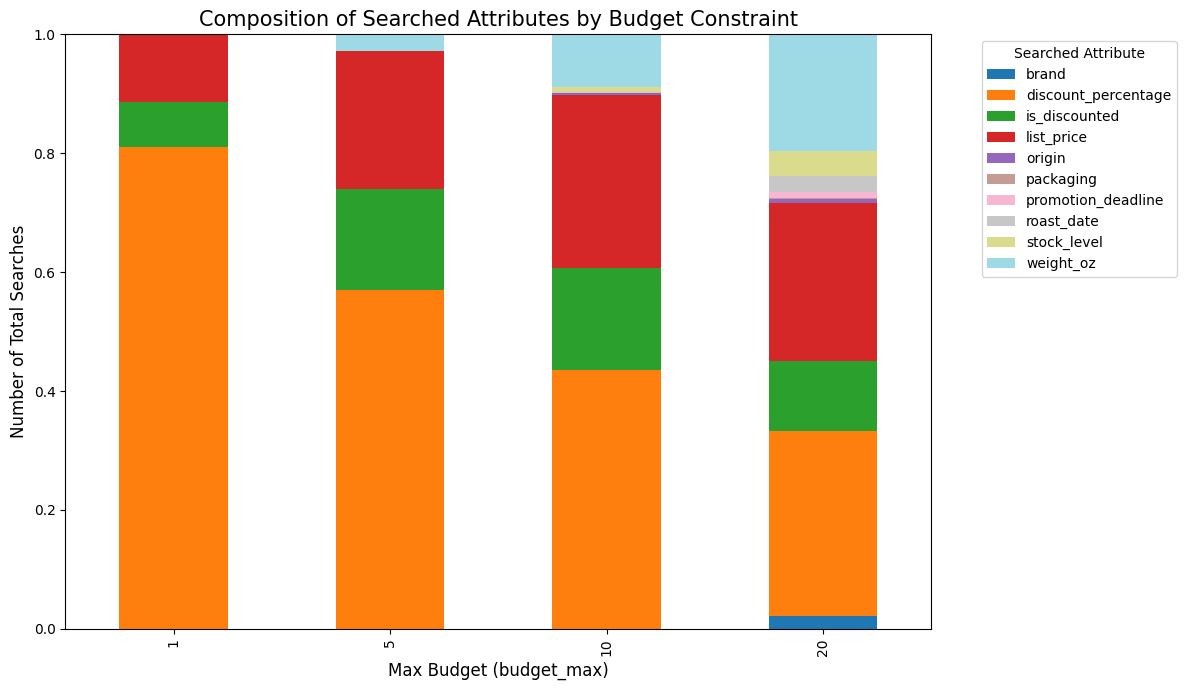

In [149]:
# 1. Create a crosstab directly from the raw df, normalizing by the row (budget)
search_proportions = pd.crosstab(
    df['budget_max'], 
    df['attribute_id'], 
    normalize='index' # Converts counts to percentages (0.0 to 1.0)
)

# 2. Plot as a Stacked Bar Chart
search_proportions.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='tab20')

plt.title('Composition of Searched Attributes by Budget Constraint', fontsize=15)
plt.xlabel('Max Budget (budget_max)', fontsize=12)
plt.ylabel('Number of Total Searches', fontsize=12)
plt.legend(title='Searched Attribute', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

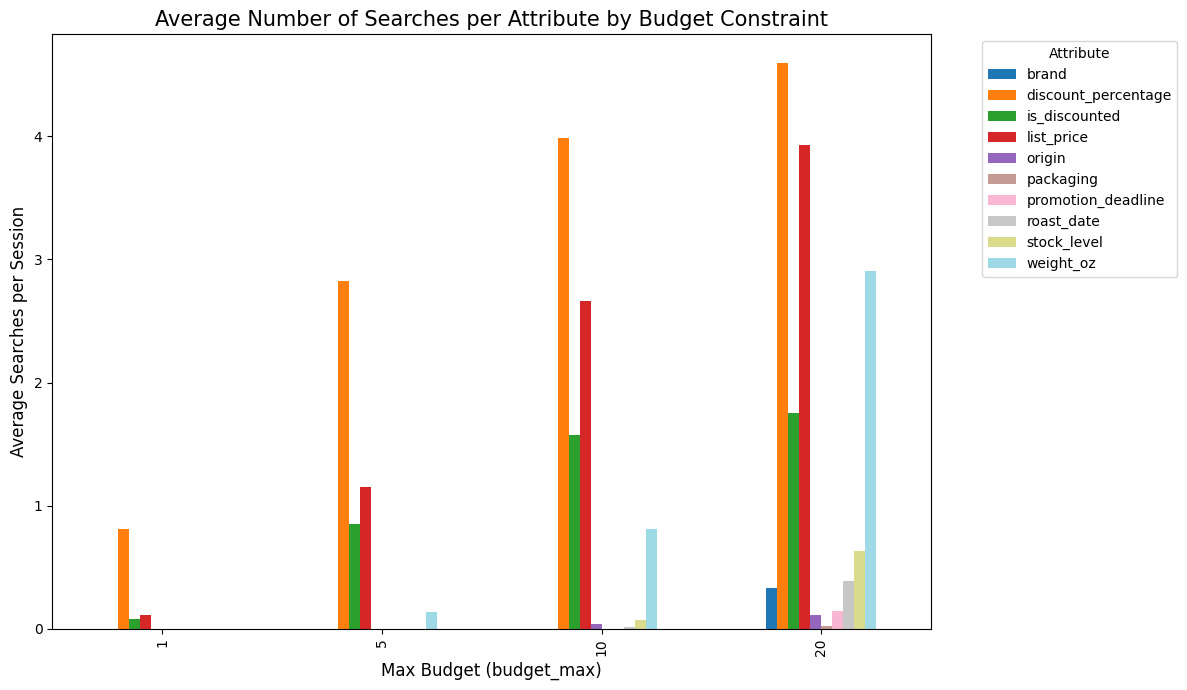

In [150]:
df_summary = (
    df.groupby(['session_name', 'budget_max'])['attribute_id']
    .value_counts()
    .unstack(fill_value=0)
    .reset_index()
)
# 1. Using the df_summary from the previous step:
# Drop 'session_name' so we only have numbers, then group by budget and get the mean
mean_searches_per_budget = df_summary.drop(columns=['session_name']).groupby('budget_max').mean()
mean_searches_per_budget

# 2. Plot as a grouped bar chart (not stacked)
mean_searches_per_budget.plot(kind='bar', figsize=(12, 7), colormap='tab20')

plt.title('Average Number of Searches per Attribute by Budget Constraint', fontsize=15)
plt.xlabel('Max Budget (budget_max)', fontsize=12)
plt.ylabel('Average Searches per Session', fontsize=12)
plt.legend(title='Attribute', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


### most_important_attribute

In [151]:
df, config = get_data(exp_name)
# (df[df['budget_max']==20]).groupby('model_name')['choice'].value_counts(dropna=False)
if df.choice.isna().sum():
    print(f'we have missing choices: {df.choice.isna().sum()}')
# df.groupby(['model_name', 'budget_max'])['session_name'].nunique()

In [152]:
df_submit_choice = (df[(df['kind']=='tool')&(df['tool_name']=='submit_choice')]).copy()
df_submit_choice_summary = (
    df_submit_choice.groupby(['budget_max'])['most_important_attribute']
    .value_counts(normalize=True)
    # .unstack(fill_value=0)
    .reset_index()
)

([0, 1, 2, 3],
 [Text(0, 0, '1'), Text(1, 0, '5'), Text(2, 0, '10'), Text(3, 0, '20')])

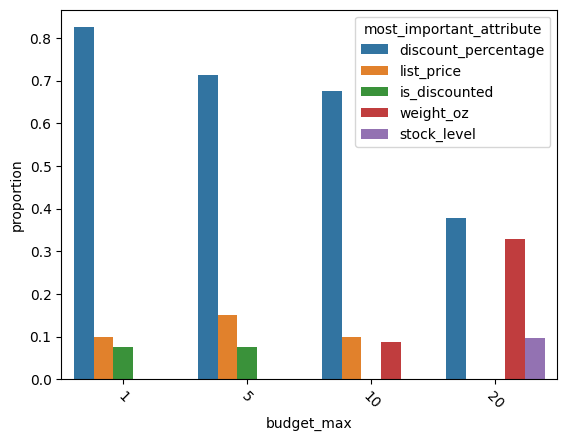

In [153]:
df_summary_count_g1 = df_submit_choice_summary[df_submit_choice_summary['proportion']>0.03]
ax = sns.barplot(data = df_summary_count_g1, hue = 'most_important_attribute', y = 'proportion', x='budget_max')
plt.xticks(rotation=-45)

In [154]:
df_submit_choice['discount_percentage_most_important'] = df_submit_choice['most_important_attribute']=='discount_percentage'
df_submit_choice['discount_percentage_most_important'].value_counts()

discount_percentage_most_important
True     208
False    114
Name: count, dtype: int64

In [155]:
import statsmodels.formula.api as smf

# Convert the boolean column to integer (0 or 1) for the model
df_submit_choice['discount_target'] = df_submit_choice['discount_percentage_most_important'].astype(int)

# Fit the logistic regression model
# This tests if continuous 'budget_max' predicts the binary 'discount_target'
logit_model = smf.logit('discount_target ~ budget_max', data=df_submit_choice).fit()

# Display the statistical summary
print(logit_model.summary())

Optimization terminated successfully.
         Current function value: 0.591378
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:        discount_target   No. Observations:                  322
Model:                          Logit   Df Residuals:                      320
Method:                           MLE   Df Model:                            1
Date:                Wed, 15 Apr 2026   Pseudo R-squ.:                 0.09006
Time:                        18:19:57   Log-Likelihood:                -190.42
converged:                       True   LL-Null:                       -209.27
Covariance Type:            nonrobust   LLR p-value:                 8.274e-10
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.5970      0.216      7.380      0.000       1.173       2.021
budget_max    -0.1027      0.